In [32]:
# need to install torch and torchvision for the code to run
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# import the image module from PIL (Python Imaging Library) to open and process image.
from PIL import Image

# import Path to work with file and folder paths
from pathlib import Path

# to display the image
import matplotlib.pyplot as plt

# for numerical operations 
import numpy as np

# PyTorch is an optimized tensor library for deep learning using GPUs and CPUs
import torch

# import torchvision transforms for image transformation and augmentation
import torchvision.transforms as T


In [34]:
# define the path to the image file
image_path = Path(r"C:\Users\ldldld\Desktop\Data Analytics and Visualisation_COMP09014\Assignments\Week 3\SNAP-28052018-083735-0021-RM5X-13.17pm-37degrees-Image13.tif")

# open image 
orig_image = Image.open(image_path)

# display basic information about the image
print("image size:", orig_image.size)
print("image mode:", orig_image.mode)

image size: (694, 520)
image mode: RGB


In [35]:
# set the random seed for reproducibility
torch.manual_seed(0)

In [36]:
def plot(images, titles=None):
    # create a figure
    plt.figure(figsize=(12, 4))

    # make sure a single image is treated as a list
    if not isinstance(images, (list, tuple)):
        images = [images]

    # create one subplot for each image
    for i, image in enumerate(images):
        plt.subplot(1, len(images), i + 1)

        # display grayscale images using a gray colormap, ### otherwise the grayscale images will be displayed in color
        if image.mode == "L":
            plt.imshow(image, cmap="gray")
        else:
            plt.imshow(image)

        # turn off the axis
        plt.axis("off")

        # add a title if provided
        if titles is not None:
            plt.title(titles[i])

    # adjust the layout
    plt.tight_layout()

    # display the image
    plt.show()

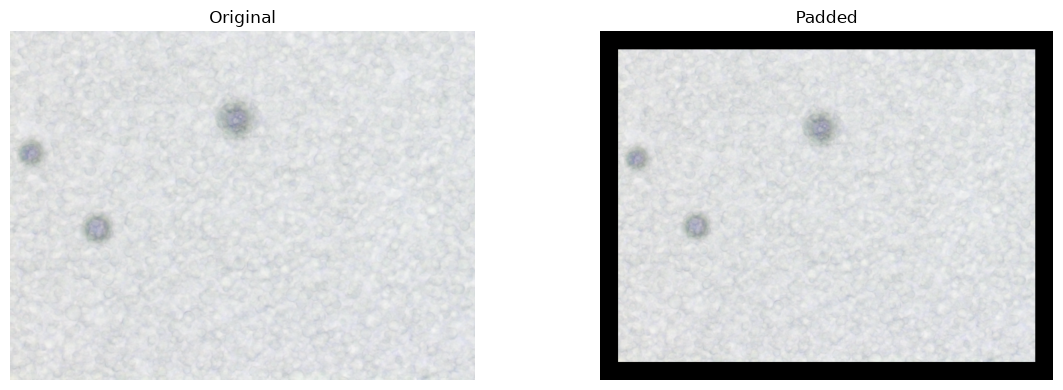

In [37]:
# Pad

# create a padding transformation with a padding of 30 pixels
padding_trans = T.Pad(padding=30)

# apply the padding transformation to the original image
padded_image = padding_trans(orig_image)

# display the original and padded image
plot([orig_image, padded_image], ["Original", "Padded"])


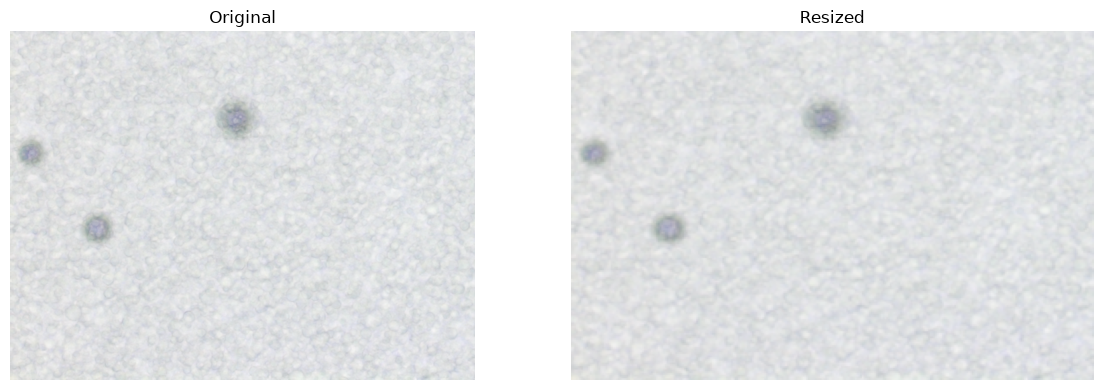

In [38]:
# Resize

# create the resize transformation 
resize_trans = T.Resize(size=(200,300)) # height 200 pixels, width 300 pixels

# apply the resize transformation to the original image
resized_image = resize_trans(orig_image)

# display both images
plot([orig_image, resized_image], ["Original", "Resized"])

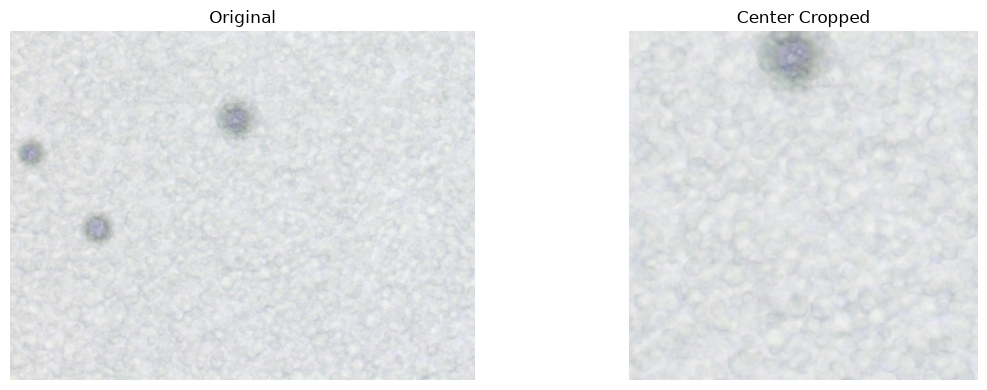

In [39]:
# CenterCrop

# create a center crop transformation with a size of 300*300 pixels
center_crop_trans = T.CenterCrop(size=(300,300))

# apply it to the original image
center_cropped_image = center_crop_trans(orig_image)

# plot both images
plot([orig_image, center_cropped_image], ["Original", "Center Cropped"])


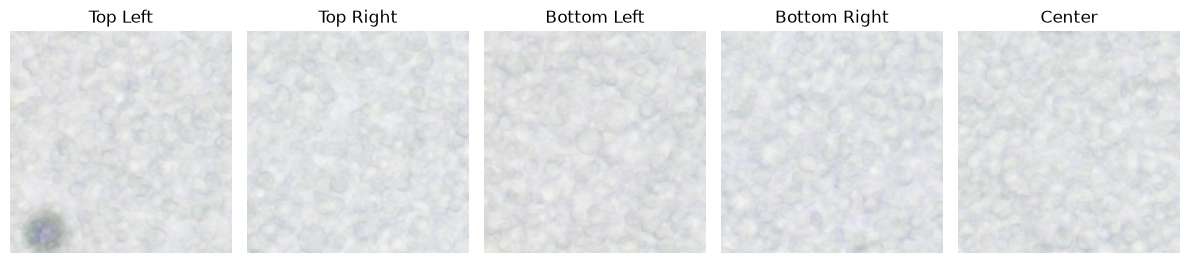

In [40]:
# FiveCrop

# create a five crop transformation with a size of 200*200 pixels
five_crop_trans = T.FiveCrop(size=(200,200))

# apply it to the original image
five_cropped_image = five_crop_trans(orig_image)

# unpack the five cropped images
top_left, top_right, bottom_left, bottom_right, center = five_cropped_image

# plot the original and the five cropped images
plot([top_left, top_right, bottom_left, bottom_right, center], ["Top Left", "Top Right", "Bottom Left", "Bottom Right", "Center"])

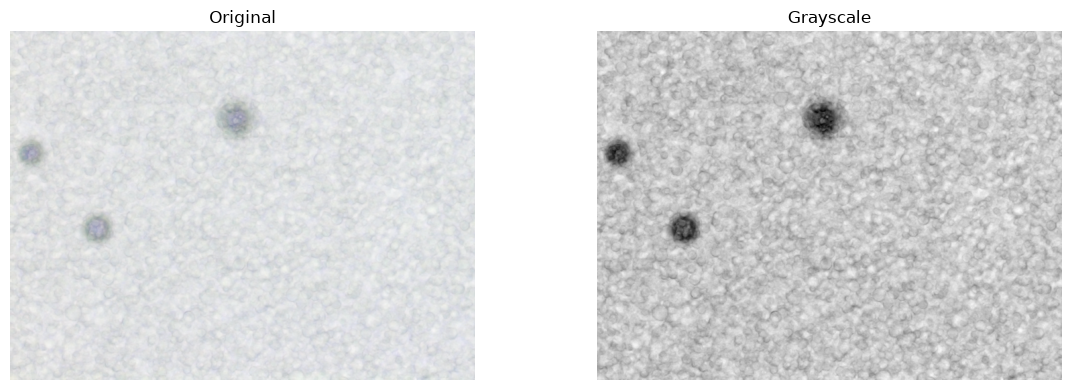

In [41]:
# Grayscale

# create a grayscale transformation
grayscale_trans = T.Grayscale()

# apply it to the original image
grayscale_image = grayscale_trans(orig_image)

# plot both images
plot([orig_image, grayscale_image], ["Original", "Grayscale"])

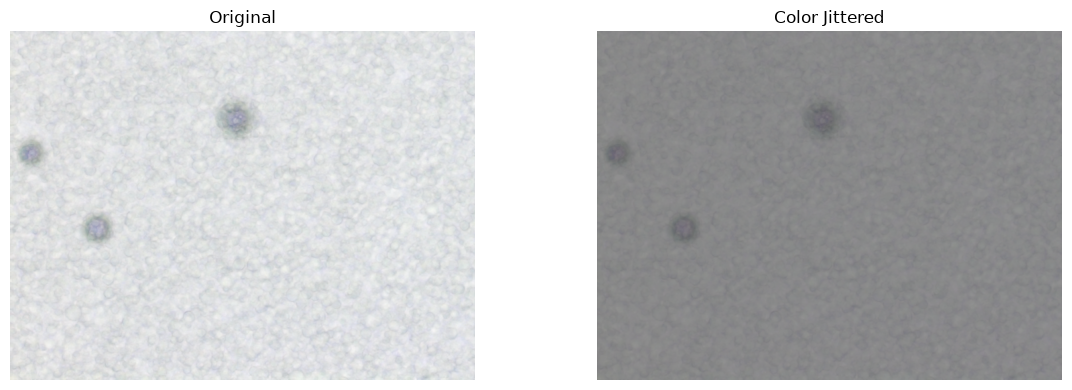

In [54]:
# ColorJitter

# create a color jitter transformation
color_jitter_trans =T.ColorJitter(brightness=0.5, contrast=0.8, hue=0.2)

# apply it to the original image
color_jittered_image = color_jitter_trans(orig_image)

# plot both images
plot([orig_image, color_jittered_image], ["Original", "Color Jittered"])

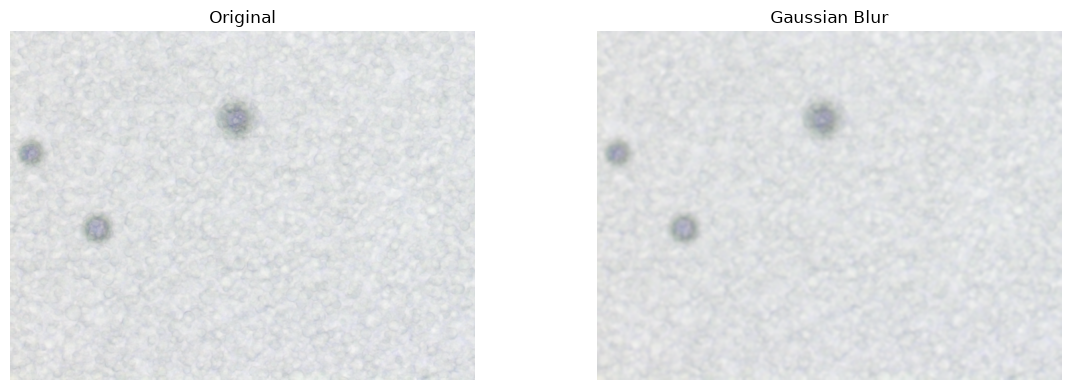

In [ ]:
# GaussianBlur

# create a Gaussian blur transformation, the bigger the kernel and sigma, the more noticeable the blur effect
gaussianblur_trans = T.GaussianBlur(kernel_size=5, sigma=(0.1, 5))

# apply the Gaussian blur transformation to the original image
gaussianblur_image = gaussianblur_trans(orig_image)

# plot both images
plot([orig_image, gaussianblur_image], ["Original", "Gaussian Blur"])

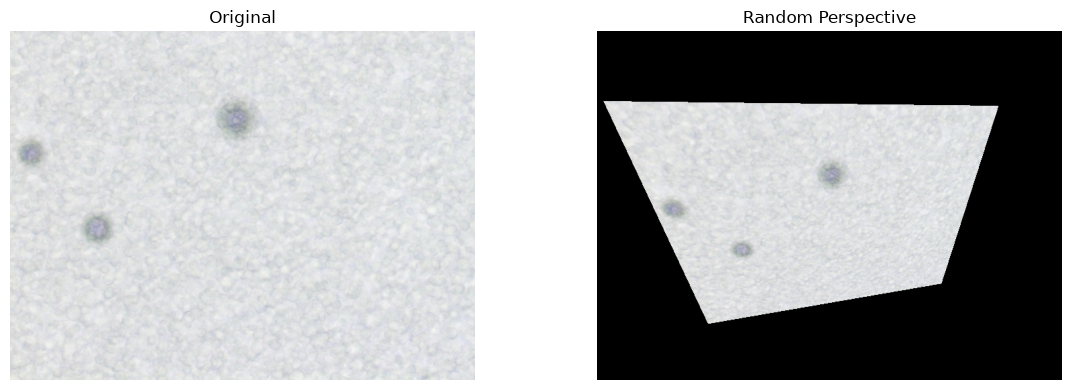

In [57]:
# RandomPerspective

# create a random perspective transformation
perspective_trans = T.RandomPerspective(distortion_scale=0.6, p=1.0) # distortion_scale controls the degree of distortion, p is the probability of applying the transformation

# apply it to the original image
perspective_image = perspective_trans(orig_image)

# plot both images
plot([orig_image, perspective_image], ["Original", "Random Perspective"])


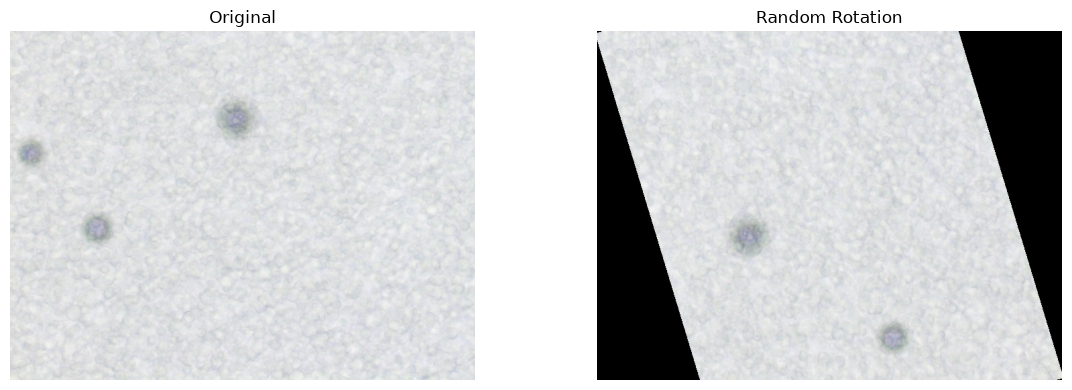

In [58]:
# RandomRotation

# create a random rotation transformation
rotation_trans = T.RandomRotation(degrees=(0, 180))

# apply it to the original image
rotation_image = rotation_trans(orig_image)

# plot both images
plot([orig_image, rotation_image], ["Original", "Random Rotation"])

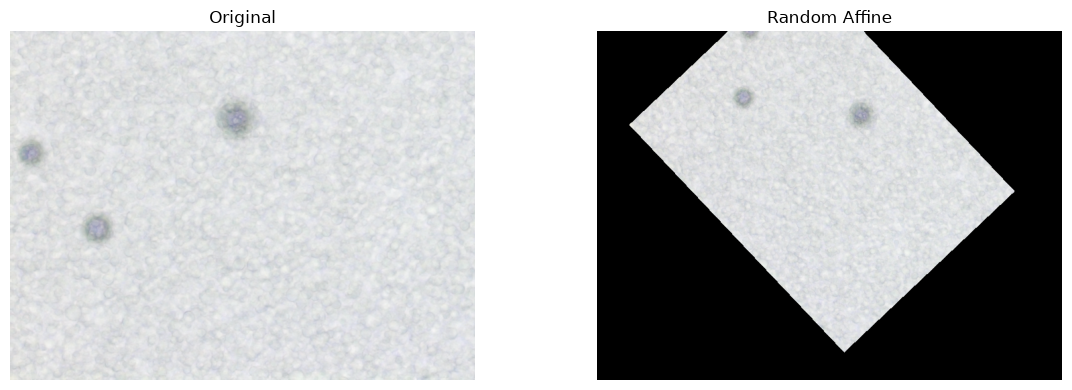

In [ ]:
# RandomAffine

# create a random affine transformation (0.1: Maximum horizontal translation, 0.3: Maximum vertical translation)
affine_trans = T.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75))

# apply it to the original image
affine_image = affine_trans(orig_image)

# plot both images
plot([orig_image, affine_image], ["Original", "Random Affine"])